## Packages

In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from glob import glob
from tqdm import tqdm
from tifffile import imread
from csbdeep.utils import Path, download_and_extract_zip_file, normalize

from stardist import fill_label_holes, relabel_image_stardist, random_label_cmap, gputools_available
from stardist.matching import matching_dataset
from stardist.models import StarDist2D

from PIL import Image
import gputools

import os 
import time 
import warnings
import shutil
warnings.filterwarnings('ignore')


np.random.seed(42)
lbl_cmap = random_label_cmap()

2025-11-26 02:22:58.096467: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
persistent_dict.py (63): Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.


If you want to compute separable approximations, please install it with
pip install scikit-tensor-py3


In [2]:
def load_image(img_path):
    image = np.array(Image.open(img_path).convert('RGB'))
    return image


def load_mask(mask_path):
    mask = np.load(mask_path)
    return mask

def plot_img_label(img, lbl, img_title="image", lbl_title="label", **kwargs):
    fig, (ai,al) = plt.subplots(1,2, figsize=(10,4), gridspec_kw=dict(width_ratios=(1.25,1)))
    im = ai.imshow(img, cmap='gray', clim=(0,1))
    ai.set_title(img_title)
    al.imshow(lbl, cmap=lbl_cmap)
    al.set_title(lbl_title)
    plt.tight_layout()

## Paths

In the following sections, paths are setting in this format:

```python
    train_image_dir = '/path/to/images' # folder of png files
    train_mask_dir = 'path/to/labels'   # folder of npy lables 

    val_image_dir = '/path/to/val/images' # folder of png files
    val_mask_dir = 'path/to/val/labels'   # folder of npy lables 

    model_name = '/path/to/saved/model/folder' # the finetuned model saved here 

```

## Load Data

### load data directly

In [ ]:
# e.g., 
train_image_dir = '/path/to/hard/100%/images'
train_mask_dir = '/path/to/hard/100%/labels'

start_time = time.time()
X = sorted(glob(os.path.join(train_image_dir, '*.png')))
Y = sorted(glob(os.path.join(train_mask_dir,'*.npy')))
assert all(Path(x).name.split('.')[0]==Path(y).name.split('.')[0] for x,y in zip(X,Y))

X_new = list(map(load_image,tqdm(X)))
Y_new = list(map(load_mask,tqdm(Y)))

print(f'Loading data took {round(time.time() - start_time, 2)} sec')

print(f'X_new[0].shape: {X_new[0].shape}')
print(f'Y_new[0].shape: {Y_new[0].shape}')

print(f'X_new[0].dtype: {X_new[0].dtype}')
print(f'Y_new[0].dtype: {Y_new[0].dtype}')

print(f'len(X_new): {len(X_new)}')



100%|██████████| 198/198 [00:00<00:00, 2742.18it/s]

Loading data took 1.47 sec
X_new[0].shape: (512, 512, 3)
Y_new[0].shape: (512, 512)
X_new[0].dtype: uint8
Y_new[0].dtype: uint16
len(X_new): 198


### load validation data

In [ ]:
val_image_dir = '/path/to/val/images'
val_mask_dir = '/path/to/val/labels'

X_val= sorted(glob(os.path.join(val_image_dir, '*.png')))
Y_val = sorted(glob(os.path.join(val_mask_dir,'*.npy')))
assert all(Path(x).name.split('.')[0]==Path(y).name.split('.')[0] for x,y in zip(X_val,Y_val))

X_val_new = list(map(load_image,tqdm(X_val)))
Y_val_new = list(map(load_mask,tqdm(Y_val)))


100%|██████████| 95/95 [00:00<00:00, 1746.45it/s]


### data visualization 

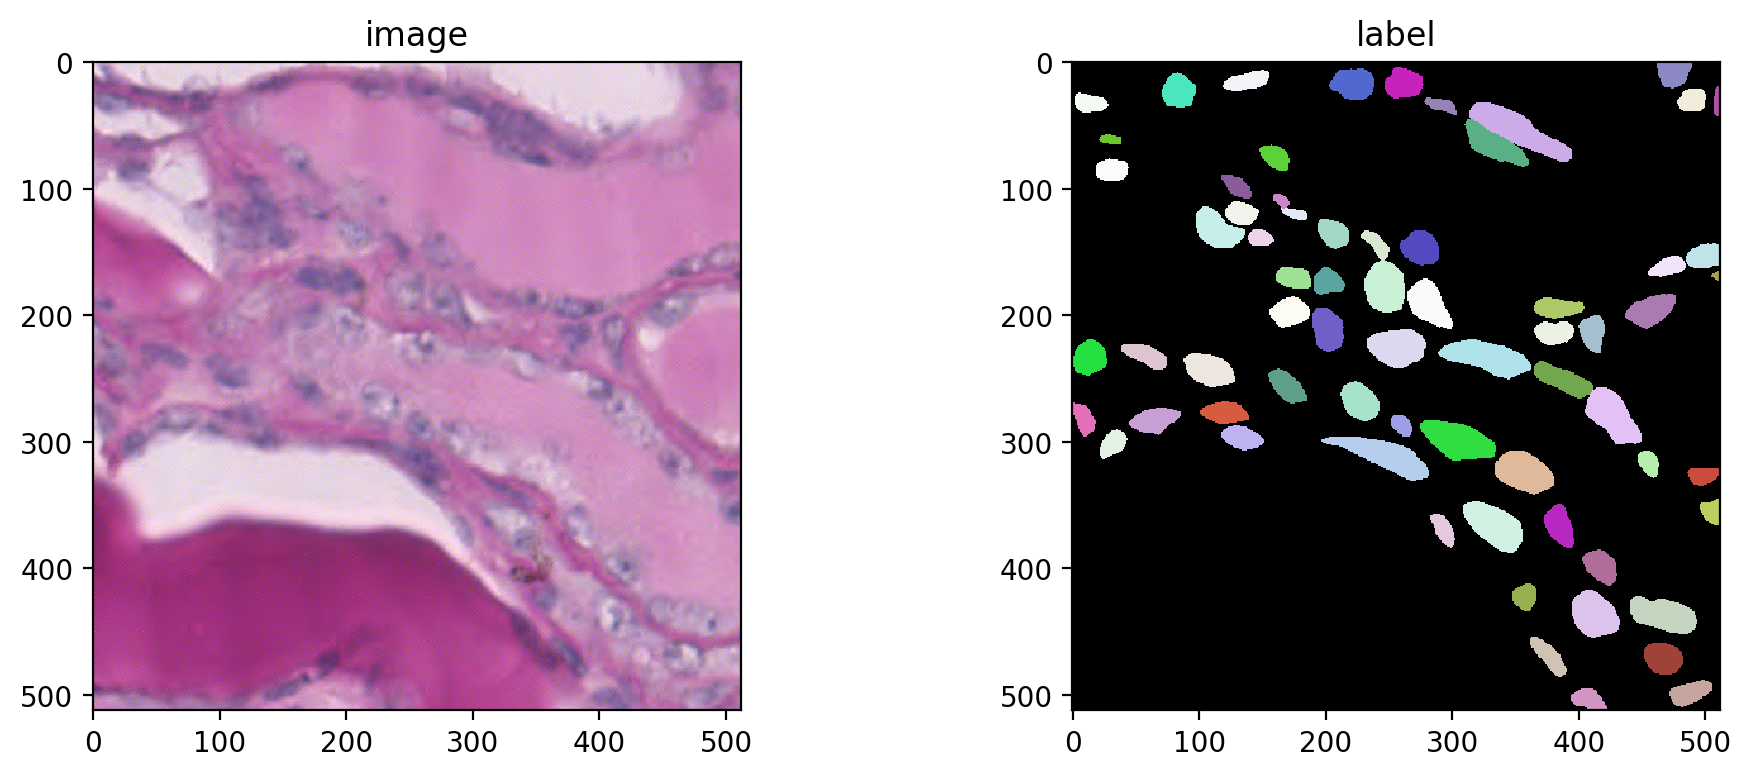

In [5]:
i = np.random.randint(0,len(X_new))
img, lbl = X_new[i], Y_new[i]
assert img.ndim in (2,3)
img = img if (img.ndim==2 or img.shape[-1]==3) else img[...,0]
plot_img_label(img,lbl)
None;


### data normalization 

In [6]:
# axis_norm = (0,1)   # normalize channels separately
axis_norm = (0,1,2) # normalize channels jointly

X_new_normalized = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X_new)]
Y_new_normalized = [fill_label_holes(y) for y in tqdm(Y_new)]


X_val_normalized = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X_val_new)]
Y_val_normalized = [fill_label_holes(y.astype(np.uint16)) for y in tqdm(Y_val_new)]

100%|██████████| 95/95 [00:00<00:00, 138.75it/s]


### augmentation

In [7]:
# data augmenter

def random_fliprot(img, mask):
    assert img.ndim >= mask.ndim
    axes = tuple(range(mask.ndim))
    perm = tuple(np.random.permutation(axes))
    img = img.transpose(perm + tuple(range(mask.ndim, img.ndim)))
    mask = mask.transpose(perm)
    for ax in axes:
        if np.random.rand() > 0.5:
            img = np.flip(img, axis=ax)
            mask = np.flip(mask, axis=ax)
    return img, mask

def random_intensity_change(img):
    img = img*np.random.uniform(0.6,2) + np.random.uniform(-0.2,0.2)
    return img


def augmenter(x, y):
    """Augmentation of a single input/label image pair.
    x is an input image
    y is the corresponding ground-truth label image
    """
    x, y = random_fliprot(x, y)
    x = random_intensity_change(x)
    # add some gaussian noise
    sig = 0.02*np.random.uniform(0,1)
    x = x + sig*np.random.normal(0,1,x.shape)
    return x, y

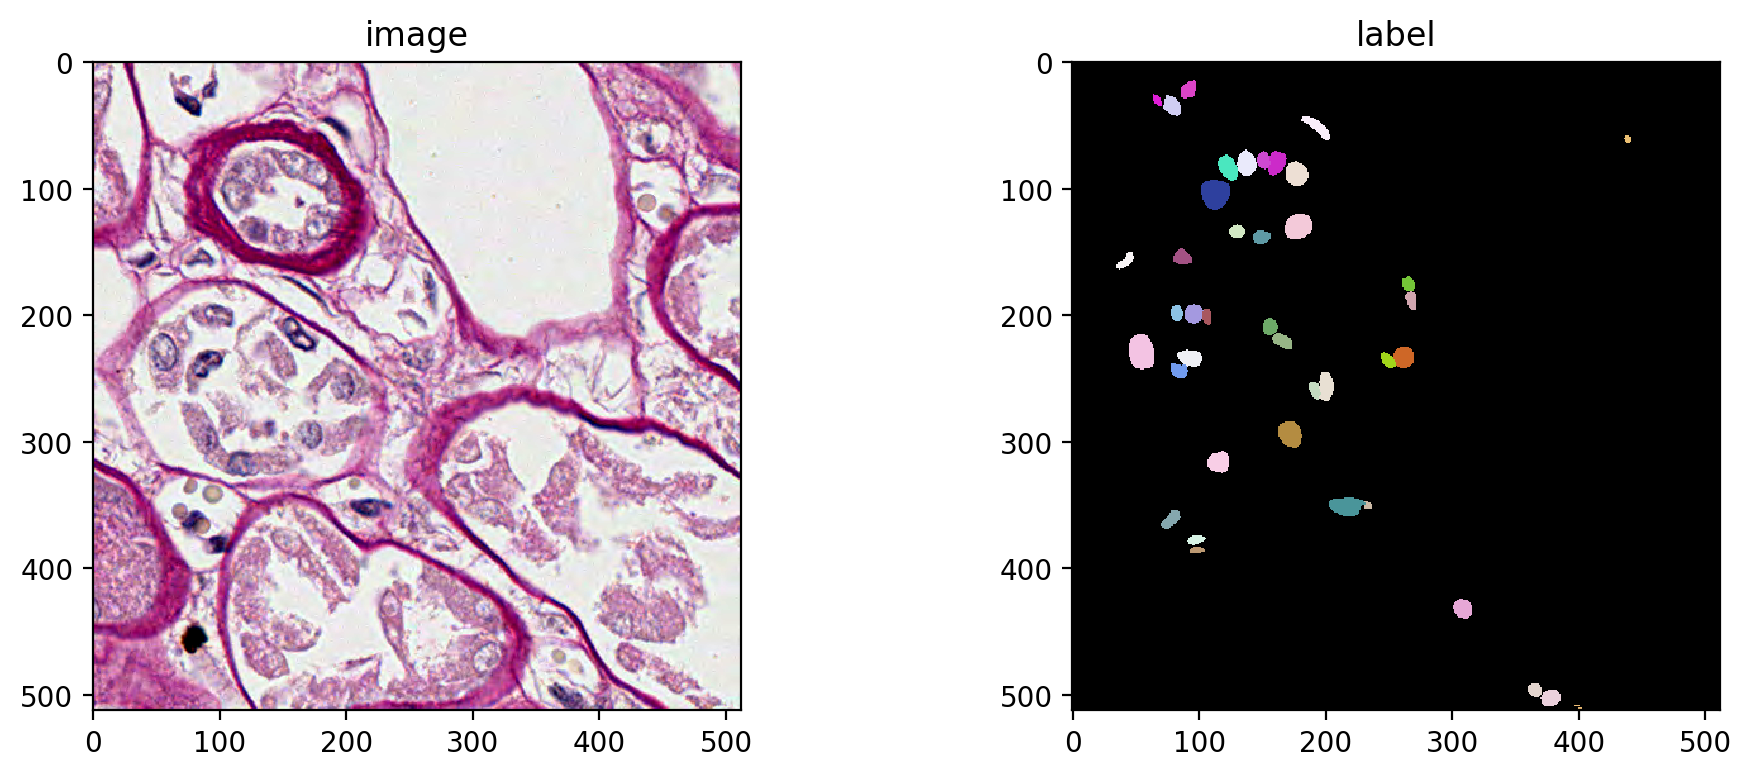

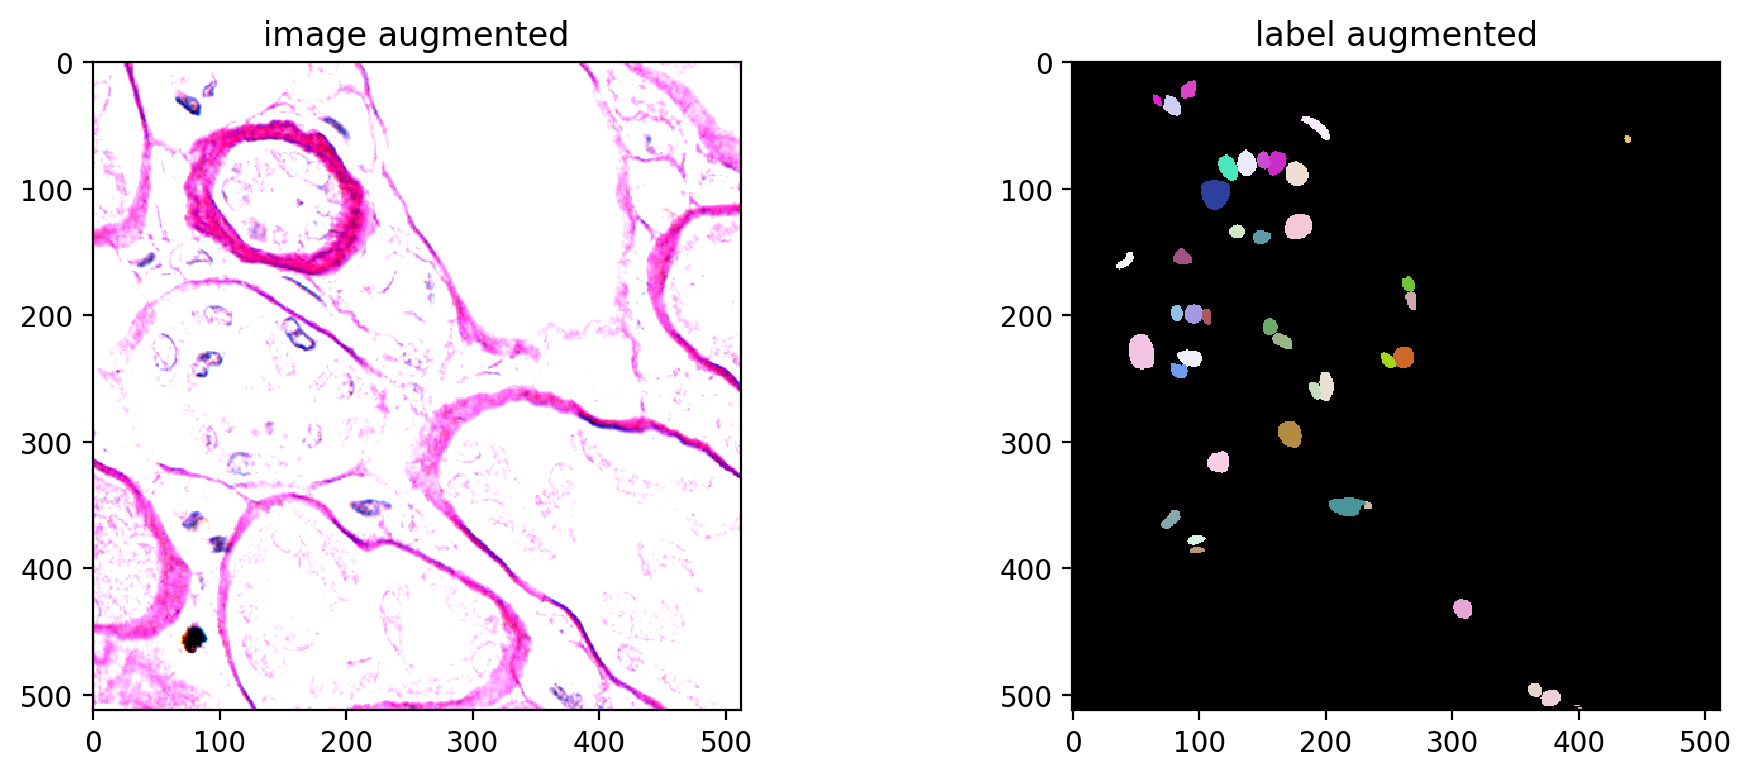

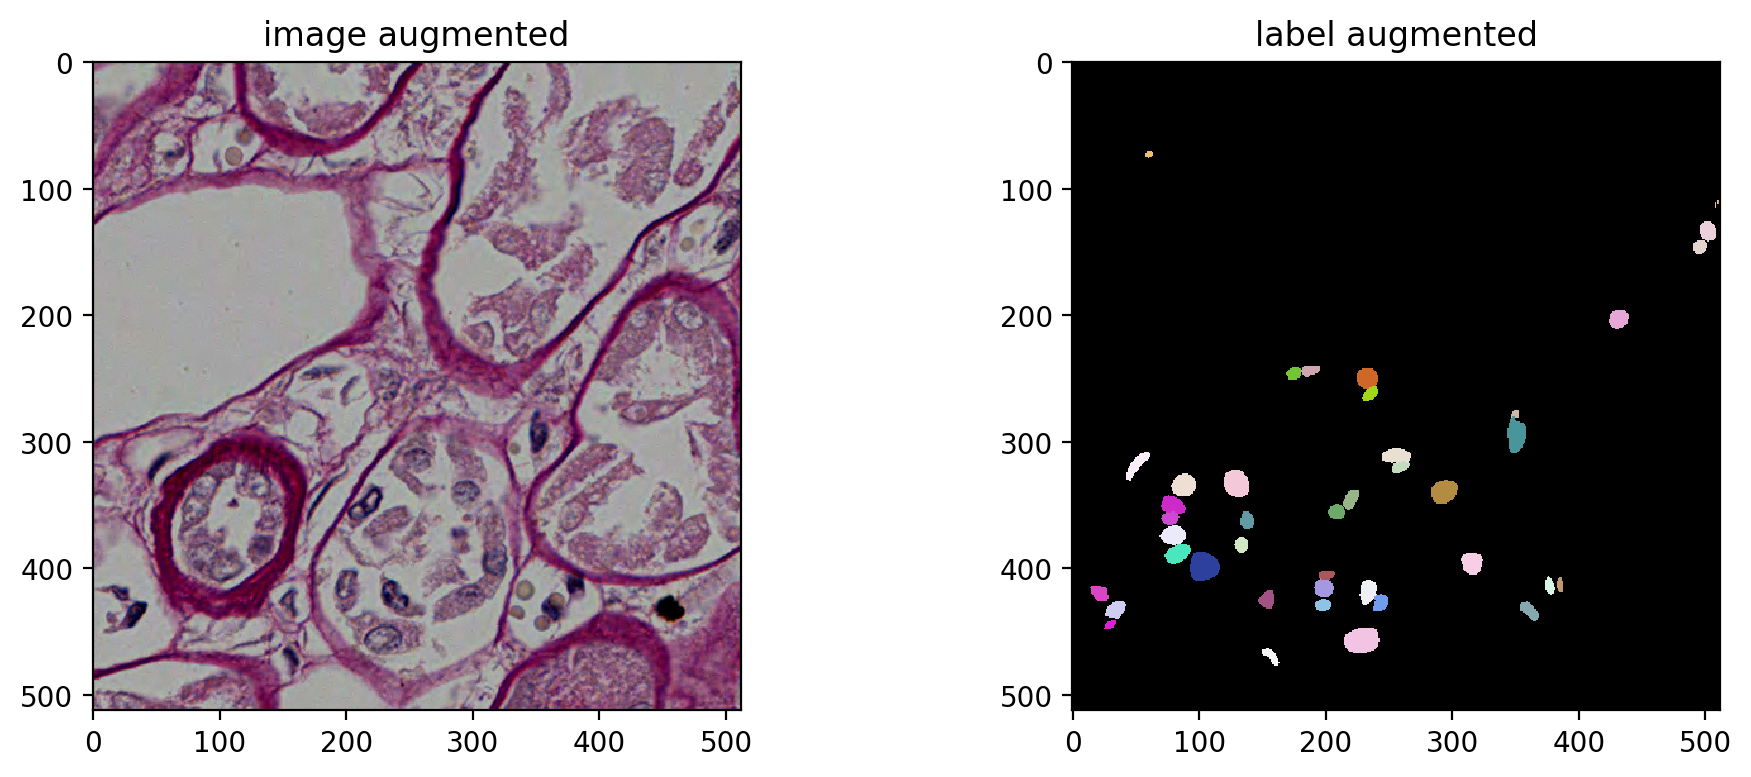

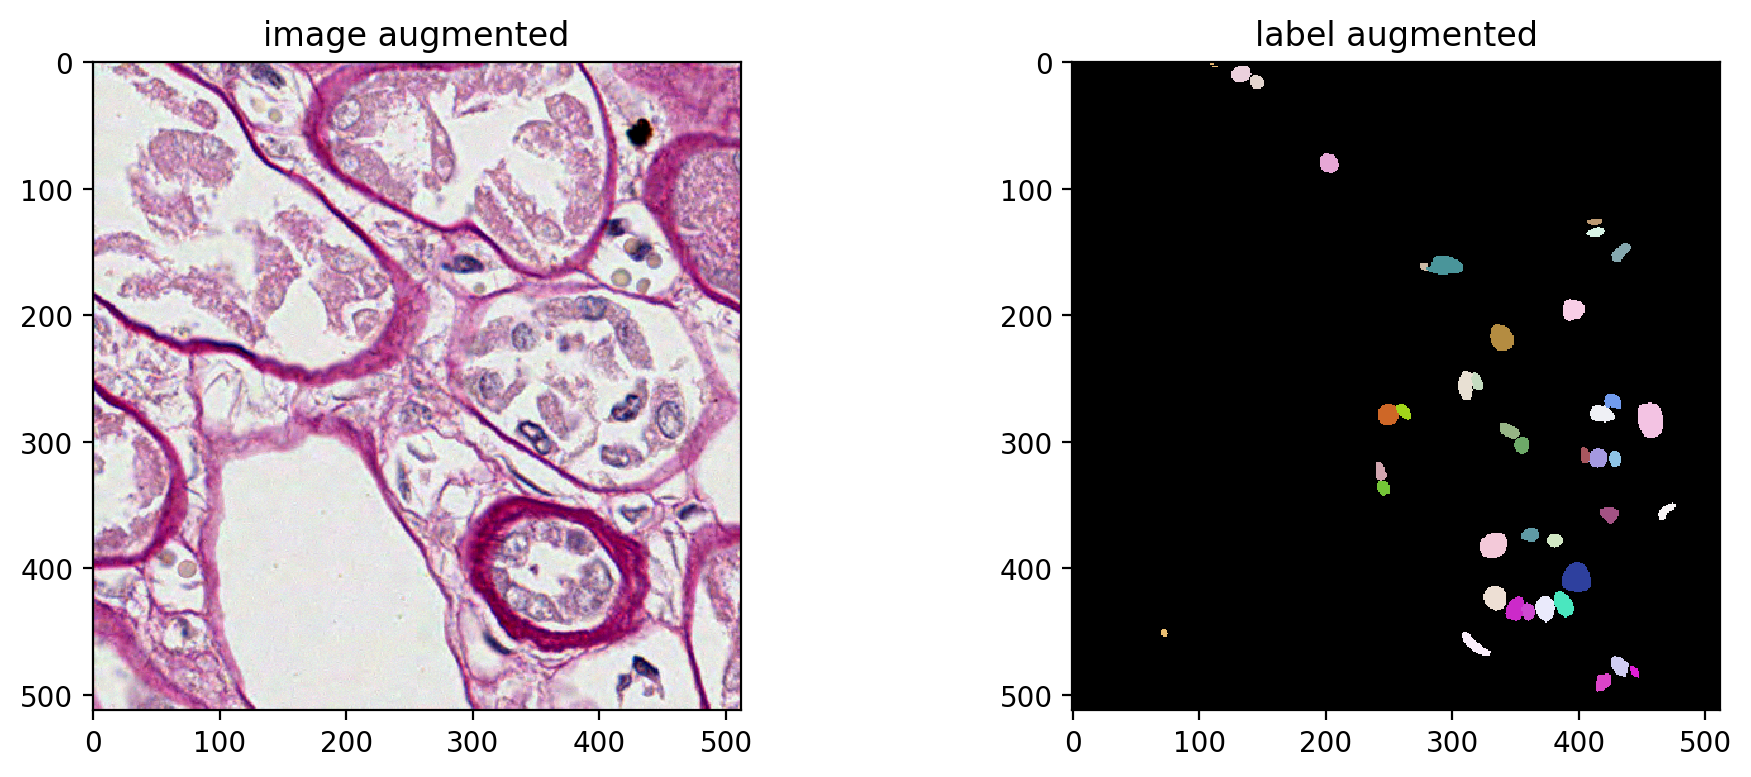

In [8]:
# plot some augmented examples
img, lbl = X_new_normalized[1],Y_new_normalized[1]
plot_img_label(img, lbl)
for _ in range(3):
    img_aug, lbl_aug = augmenter(img,lbl)
    plot_img_label(img_aug, lbl_aug, img_title="image augmented", lbl_title="label augmented")


### data split

In [9]:
X_val, Y_val = X_val_normalized, Y_val_normalized
X_trn, Y_trn = X_new_normalized, Y_new_normalized
print('number of images:')
print('- training:       %3d' % len(X_trn))
print('- validation:     %3d' % len(X_val))

number of images:
- training:       198
- validation:      95


## Training Model

In [ ]:
# save fine-tuned model at this path
model_name = '/path/to/output/model/model_hard_100'


# make a copy of a pretrained model into model_name folder
model_pretrained = StarDist2D.from_pretrained('2D_versatile_he')
shutil.copytree(model_pretrained.logdir, model_name, dirs_exist_ok=True)


# create new model from folder (loading the pretrained weights)
model = StarDist2D(None, model_name)

Found model '2D_versatile_he' for 'StarDist2D'.


2025-11-26 02:23:08.627856: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-11-26 02:23:08.627972: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-11-26 02:23:08.633449: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:65:00.0 name: NVIDIA RTX A5000 computeCapability: 8.6
coreClock: 1.695GHz coreCount: 64 deviceMemorySize: 23.67GiB deviceMemoryBandwidth: 715.34GiB/s
2025-11-26 02:23:08.633478: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2025-11-26 02:23:08.635019: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.11
2025-11-26 02:23:08.635087: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublasLt.so.11
2025

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


In [11]:
# change some training params
model.config.use_gpu = True
model.config.train_batch_size = 16
model.config.train_epochs = 50 # default 200
# model.config.train_learning_rate = 1e-5 #default 0.0003

epochs=50
steps_per_epoch = 10

In [12]:
# finetune on new data
start_time = time.time()
history = model.train(X_trn, Y_trn, validation_data=(X_val, Y_val), augmenter=augmenter, epochs=epochs, steps_per_epoch=steps_per_epoch)
model.optimize_thresholds(X_val, Y_val)
print(f'run time: {time.time() - start_time}')

2025-11-26 02:23:10.571550: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2025-11-26 02:23:10.571841: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 3899935000 Hz


Epoch 1/50


2025-11-26 02:23:12.065700: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.8
2025-11-26 02:23:13.849456: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.11
2025-11-26 02:23:14.316118: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublasLt.so.11


10/10 [==============================] - 17s 1s/step - loss: 0.3048 - prob_loss: 0.0814 - dist_loss: 2.2332 - prob_kld: 0.0404 - dist_relevant_mae: 2.2326 - dist_relevant_mse: 14.2070 - dist_dist_iou_metric: 0.6626 - val_loss: 0.2944 - val_prob_loss: 0.1113 - val_dist_loss: 1.8304 - val_prob_kld: 0.0322 - val_dist_relevant_mae: 1.8297 - val_dist_relevant_mse: 6.6818 - val_dist_dist_iou_metric: 0.6896
Epoch 2/50
10/10 [==============================] - 10s 1s/step - loss: 0.2615 - prob_loss: 0.0735 - dist_loss: 1.8798 - prob_kld: 0.0309 - dist_relevant_mae: 1.8791 - dist_relevant_mse: 10.0487 - dist_dist_iou_metric: 0.6965 - val_loss: 0.2768 - val_prob_loss: 0.1063 - val_dist_loss: 1.7049 - val_prob_kld: 0.0272 - val_dist_relevant_mae: 1.7044 - val_dist_relevant_mse: 6.3410 - val_dist_dist_iou_metric: 0.7006
Epoch 3/50
10/10 [==============================] - 13s 1s/step - loss: 0.2592 - prob_loss: 0.0644 - dist_loss: 1.9477 - prob_kld: 0.0250 - dist_relevant_mae: 1.9471 - dist_relevant

NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:34<00:11,  2.29s/it, 0.723 -> 0.704]


Using optimized values: prob_thresh=0.725131, nms_thresh=0.3.
Saving to 'thresholds.json'.
run time: 731.9691956043243


## Predictions

In our example, the validation data is also pseudo labels. So we will display the plot and visually check the segmentation quality. The evaluation should be measured on hold-out test set with ground truth label

NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:31<00:10,  2.08s/it, 0.723 -> 0.704]


Using optimized values: prob_thresh=0.725131, nms_thresh=0.3.
Saving to 'thresholds.json'.


100%|██████████| 95/95 [00:05<00:00, 17.60it/s]


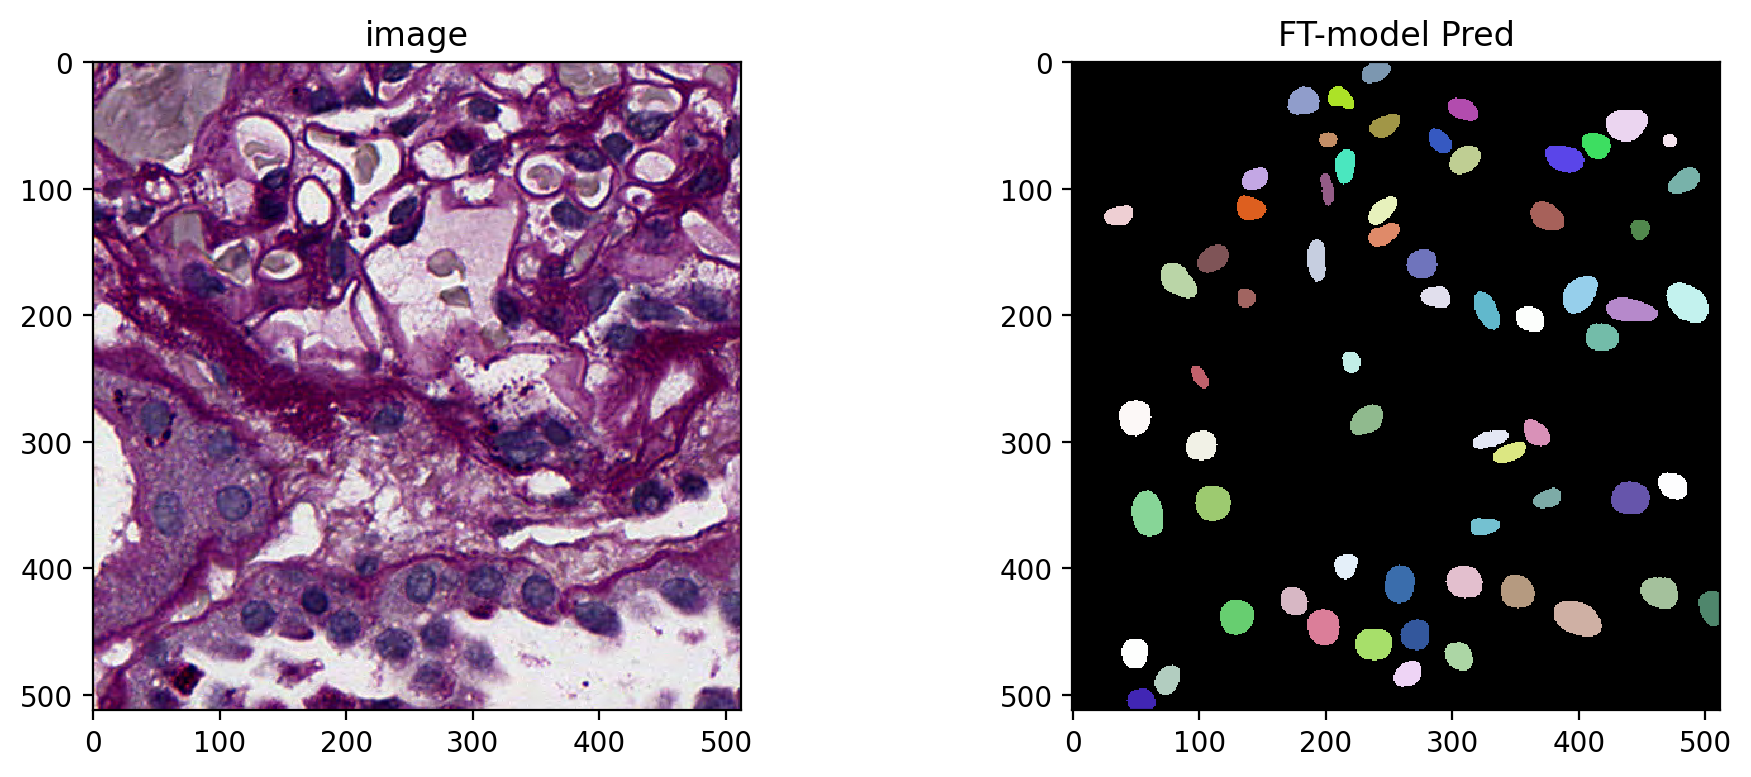

In [13]:
model.optimize_thresholds(X_val, Y_val)

Y_val_pred = [model.predict_instances(x, n_tiles=model._guess_n_tiles(x), show_tile_progress=False)[0]
              for x in tqdm(X_val)]

plot_img_label(X_val[0],Y_val_pred[0], lbl_title="FT-model Pred")

https://nbviewer.org/github/stardist/stardist/blob/main/examples/2D/2_training.ipynb (Detailed reference from official github)

## original baseline model performance

Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


100%|██████████| 95/95 [00:05<00:00, 17.02it/s]


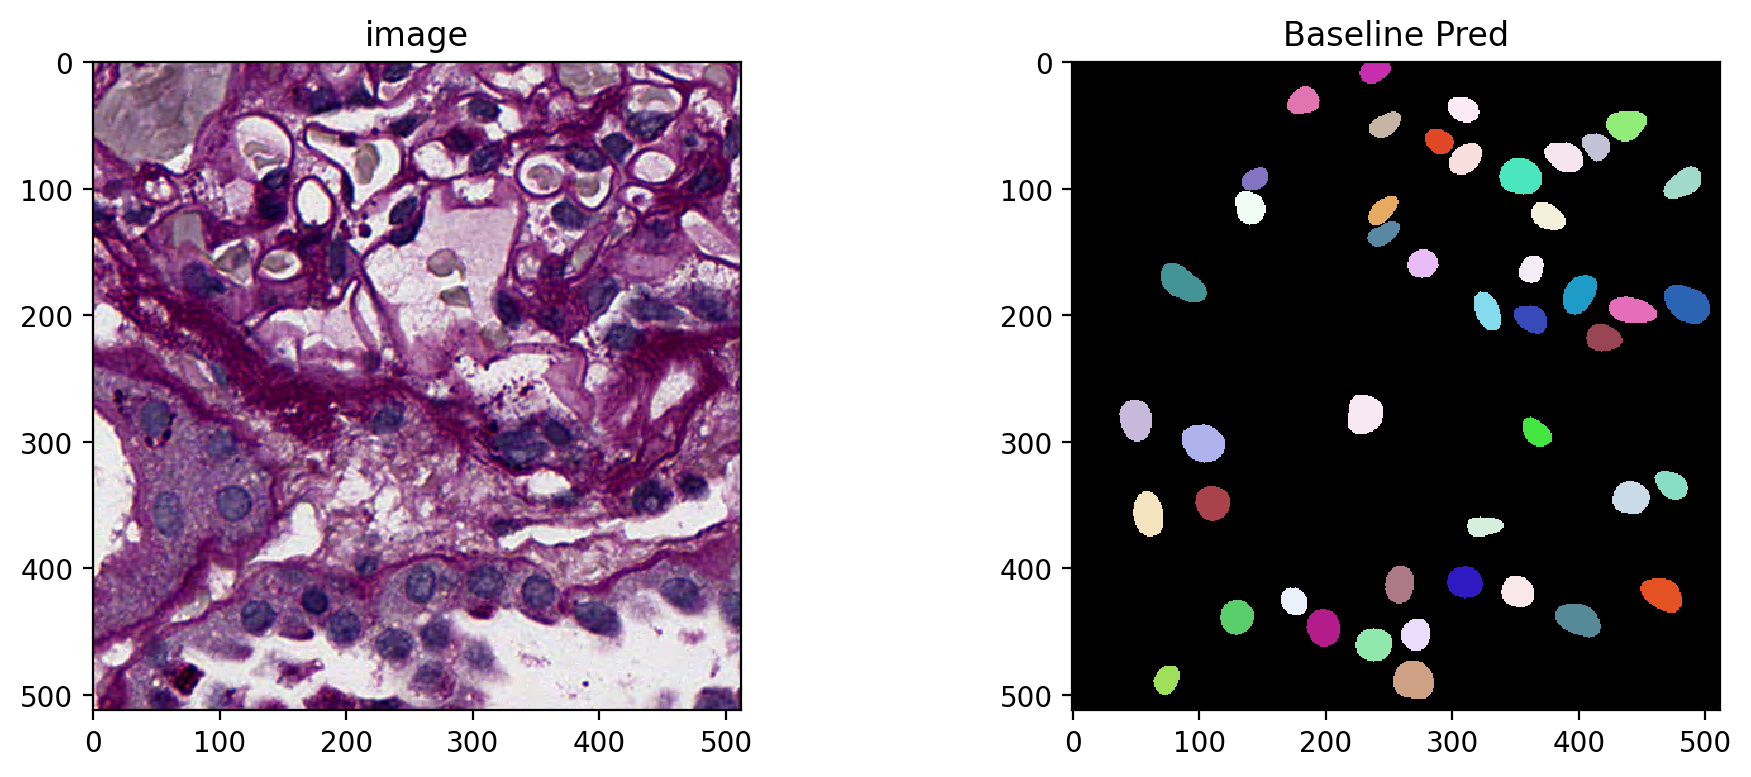

In [14]:
baseline = StarDist2D.from_pretrained('2D_versatile_he')

Y_val_pred2 = [baseline.predict_instances(x, n_tiles=model._guess_n_tiles(x), show_tile_progress=False)[0]
              for x in tqdm(X_val)]
              
plot_img_label(X_val[0],Y_val_pred2[0], lbl_title="Baseline Pred")